# some libraries and function definitions

In [10]:
# refactored_medmnist_workflow.py

from __future__ import annotations

import copy
import math
import random
import subprocess
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from torchvision import transforms
from dadapy.data import Data
import dadapy

# import sys
# !{sys.executable} -m pip install dadapy


# =========================
# Optional dependency setup
# =========================
def ensure_package(package_name: str) -> None:
    # Install a package if it's not already available.
    try:
        __import__(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


ensure_package("medmnist")

try:
    ensure_package("skdim")
    import skdim  # type: ignore

    HAS_SKDIM = True
except Exception:
    HAS_SKDIM = False

import medmnist
from medmnist import INFO


# =========================
# Configuration
# =========================
@dataclass
class Config:
    dataset_flag: str = "bloodmnist"
    batch_size: int = 128
    probe_batch_size: int = 256
    learning_rate: float = 1e-3
    num_epochs: int = 20
    random_seed: int = 42


# =========================
# Model
# =========================
class SimpleMedMNISTCNN(nn.Module):
    def __init__(self, in_channels: int, n_classes: int, input_hw: tuple[int, int] = (28, 28)) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14 -> 7
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 7 -> 3
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, *input_hw)
            flat_dim = int(np.prod(self.features(dummy).shape[1:]))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 128),
            nn.LeakyReLU(),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


# =========================
# Core utilities
# =========================
def set_seed(seed: int) -> None:
    # Set random seeds for reproducibility across numpy, torch, and cuda.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def prepare_targets(y: torch.Tensor | np.ndarray) -> torch.Tensor:
    # Convert targets to long tensor format, flattening to 1D if needed.
    if isinstance(y, np.ndarray):
        y = torch.from_numpy(y)
    return y.view(-1).long()


def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    # Compute accuracy by comparing argmax predictions to ground truth labels.
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    # Train model for one epoch and return average loss and accuracy.
    model.train()
    loss_sum, acc_sum, n = 0.0, 0.0, 0

    for x, y in loader:
        x = x.to(device)
        y = prepare_targets(y).to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1

    return loss_sum / max(n, 1), acc_sum / max(n, 1)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> tuple[float, float]:
    # Evaluate model on loader without computing gradients, returning loss and accuracy.
    model.eval()
    loss_sum, acc_sum, n = 0.0, 0.0, 0

    for x, y in loader:
        x = x.to(device)
        y = prepare_targets(y).to(device)

        logits = model(x)
        loss = criterion(logits, y)

        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1

    return loss_sum / max(n, 1), acc_sum / max(n, 1)


@torch.no_grad()
def evaluate_model_directly(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    class_names: list[str] | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Evaluate model, compute metrics, and display confusion matrix; return true labels, predictions, and logits.
    model.eval()
    y_true_all, y_pred_all, logits_all = [], [], []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_true = y_batch.view(-1).cpu().numpy()

        logits = model(x_batch)
        y_pred = logits.argmax(dim=1).cpu().numpy()

        y_true_all.append(y_true)
        y_pred_all.append(y_pred)
        logits_all.append(logits.cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    logits = np.concatenate(logits_all)

    print("\nDirect model metrics")
    print("--------------------")
    print("Accuracy         :", round(accuracy_score(y_true, y_pred), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y_true, y_pred), 4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=90, colorbar=True)
    plt.title("Direct CNN confusion matrix")
    plt.tight_layout()
    plt.show()

    return y_true, y_pred, logits


# =========================
# Representation functions
# =========================
def extract_raw_input_matrix(loader: DataLoader, max_samples: int | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Extract raw input pixels (flattened), raw tensors, and labels from dataloader.
    all_x_raw, all_x_flat, all_y = [], [], []
    seen = 0

    for x_batch, y_batch in loader:
        x_raw = x_batch.detach().cpu()
        x_flat = torch.flatten(x_raw, start_dim=1)
        y = y_batch.view(-1).detach().cpu()

        all_x_raw.append(x_raw)
        all_x_flat.append(x_flat)
        all_y.append(y)

        seen += x_batch.size(0)
        if max_samples is not None and seen >= max_samples:
            break

    X_raw = torch.cat(all_x_raw, dim=0)
    X_flat = torch.cat(all_x_flat, dim=0)
    y = torch.cat(all_y, dim=0)

    if max_samples is not None:
        X_raw = X_raw[:max_samples]
        X_flat = X_flat[:max_samples]
        y = y[:max_samples]

    return X_raw.numpy(), X_flat.numpy(), y.numpy()


def run_pca(X: np.ndarray, n_components: int = 2, standardize: bool = True) -> tuple[np.ndarray, PCA, StandardScaler | None]:
    # Apply PCA to data (optionally standardized) and return transformed data, PCA object, and scaler.
    if standardize:
        scaler = StandardScaler()
        X_in = scaler.fit_transform(X)
    else:
        scaler = None
        X_in = X

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_in)
    return X_pca, pca, scaler


def plot_pca_scatter(
    X_pca: np.ndarray,
    y: np.ndarray,
    pca: PCA,
    title: str,
    class_names: list[str] | None = None,
) -> None:
    # Visualize PCA-reduced data as a 2D scatter plot with class labels and variance explained.
    plt.figure(figsize=(12, 5))
    sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=8, alpha=0.75, cmap="tab10")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
    plt.title(title)

    if class_names is not None:
        cbar = plt.colorbar(sc)
        cbar.set_ticks(np.arange(len(class_names)))
        cbar.set_ticklabels(class_names)

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def extract_representations(
    model: SimpleMedMNISTCNN,
    loader: DataLoader,
    device: torch.device,
    rep: str = "penultimate",
) -> tuple[np.ndarray, np.ndarray]:
    # Extract intermediate or final representations from model (penultimate, logits, or conv_flat) and labels.
    model.eval()
    all_Z, all_y = [], []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch_np = y_batch.view(-1).cpu().numpy()

        if rep == "penultimate":
            h = model.features(x_batch)
            z = model.classifier[:5](h)
        elif rep == "logits":
            z = model(x_batch)
        elif rep == "conv_flat":
            h = model.features(x_batch)
            z = torch.flatten(h, start_dim=1)
        else:
            raise ValueError("rep must be one of: 'penultimate', 'logits', 'conv_flat'.")

        all_Z.append(z.detach().cpu().numpy())
        all_y.append(y_batch_np)

    return np.concatenate(all_Z, axis=0), np.concatenate(all_y, axis=0)


def summarize_representation(Z: np.ndarray, y: np.ndarray, name: str) -> None:
    # Print statistics about representation quality: variance, silhouette score, and nearest-centroid accuracy.
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape:", Z.shape)

    Z_scaled = StandardScaler().fit_transform(Z)
    pca = PCA().fit(Z_scaled)

    print("PC1 variance:", round(float(pca.explained_variance_ratio_[0]), 4))
    if Z.shape[1] >= 2:
        print("PC1+PC2 variance:", round(float(pca.explained_variance_ratio_[:2].sum()), 4))

    unique, counts = np.unique(y, return_counts=True)
    if len(unique) > 1 and np.min(counts) > 1:
        print("Silhouette score:", round(float(silhouette_score(Z_scaled, y)), 4))
    else:
        print("Silhouette score: skipped")

    centroids = np.stack([Z_scaled[y == cls].mean(axis=0) for cls in unique], axis=0)
    dists = np.linalg.norm(Z_scaled[:, None, :] - centroids[None, :, :], axis=2)
    pred_labels = unique[np.argmin(dists, axis=1)]
    print("Nearest-centroid acc:", round(float(accuracy_score(y, pred_labels)), 4))


def linear_probe(train_Z: np.ndarray, train_y: np.ndarray, test_Z: np.ndarray, test_y: np.ndarray) -> LogisticRegression:
    # Train logistic regression on representations and evaluate train/test accuracy; assess representation quality.
    scaler = StandardScaler()
    train_Z_scaled = scaler.fit_transform(train_Z)
    test_Z_scaled = scaler.transform(test_Z)

    clf = LogisticRegression(max_iter=2000, n_jobs=-1, multi_class="auto")
    clf.fit(train_Z_scaled, train_y)

    train_acc = accuracy_score(train_y, clf.predict(train_Z_scaled))
    test_acc = accuracy_score(test_y, clf.predict(test_Z_scaled))

    print("\nLinear probe")
    print("------------")
    print("Train accuracy:", round(float(train_acc), 4))
    print("Test accuracy :", round(float(test_acc), 4))
    return clf


def estimate_intrinsic_dimension(Z: np.ndarray, name: str, k_list: list[int] | None = None) -> dict[str, float]:
    # Estimate intrinsic dimensionality using TwoNN, MLE, and TLE methods with varying k values.
    k_list = k_list or [10, 20, 30, 50]
    print(f"\n{name}")
    print("-" * len(name))
    print("Input shape:", Z.shape)

    if not HAS_SKDIM:
        print("skdim unavailable: skipped")
        return {}

    Z_scaled = StandardScaler().fit_transform(Z)
    results: dict[str, float] = {}

    try:
        d_twonn = float(skdim.id.TwoNN().fit_transform(Z_scaled))
        results["TwoNN"] = d_twonn
        print("TwoNN:", round(d_twonn, 2))
    except Exception as e:
        print("TwoNN failed:", e)

    for k in k_list:
        print(f"\nk = {k}")
        try:
            d_mle = float(skdim.id.MLE(K=k).fit_transform(Z_scaled))
            results[f"MLE_k{k}"] = d_mle
            print("MLE :", round(d_mle, 2))
        except Exception as e:
            print("MLE failed:", e)

        try:
            d_tle = float(skdim.id.TLE().fit_transform(Z_scaled, n_neighbors=k))
            results[f"TLE_k{k}"] = d_tle
            print("TLE :", round(d_tle, 2))
        except Exception as e:
            print("TLE failed:", e)

    return results


# workflow for a MedMINST data:

Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Epoch 01/20 | train loss: 1.6099 | train acc: 0.3702 | val loss: 1.1596 | val acc: 0.5303
Epoch 02/20 | train loss: 0.9888 | train acc: 0.6139 | val loss: 0.7997 | val acc: 0.6817
Epoch 03/20 | train loss: 0.8004 | train acc: 0.6896 | val loss: 0.7051 | val acc: 0.7232
Epoch 04/20 | train loss: 0.7291 | train acc: 0.7185 | val loss: 0.6827 | val acc: 0.7288
Epoch 05/20 | train loss: 0.6993 | train acc: 0.7330 | val loss: 0.6342 | val acc: 0.7571
Epoch 06/20 | train loss: 0.6598 | train acc: 0.7490 | val loss: 0.6396 | val acc: 0.7502
Epoch 07/20 | train loss: 0.6299 | train acc: 0.7584 | val loss: 0.6642 | val acc: 0.7440
Epoch 08/20 | train loss: 0.5921 | train acc: 0.7736 | val loss: 0.5515 | val acc: 0.7894
Epoch 09/20 | train loss: 0.5519 | train ac

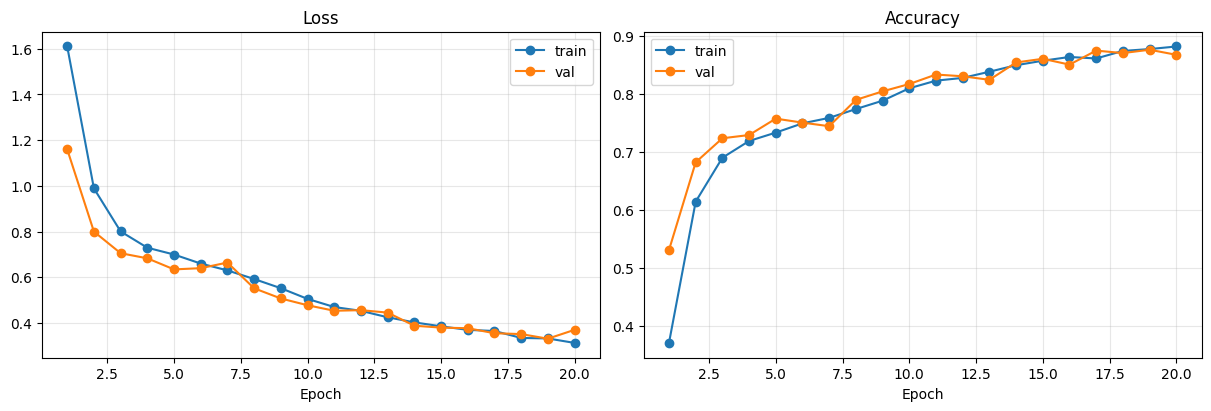


Direct model metrics
--------------------
Accuracy         : 0.8743
Balanced accuracy: 0.8484


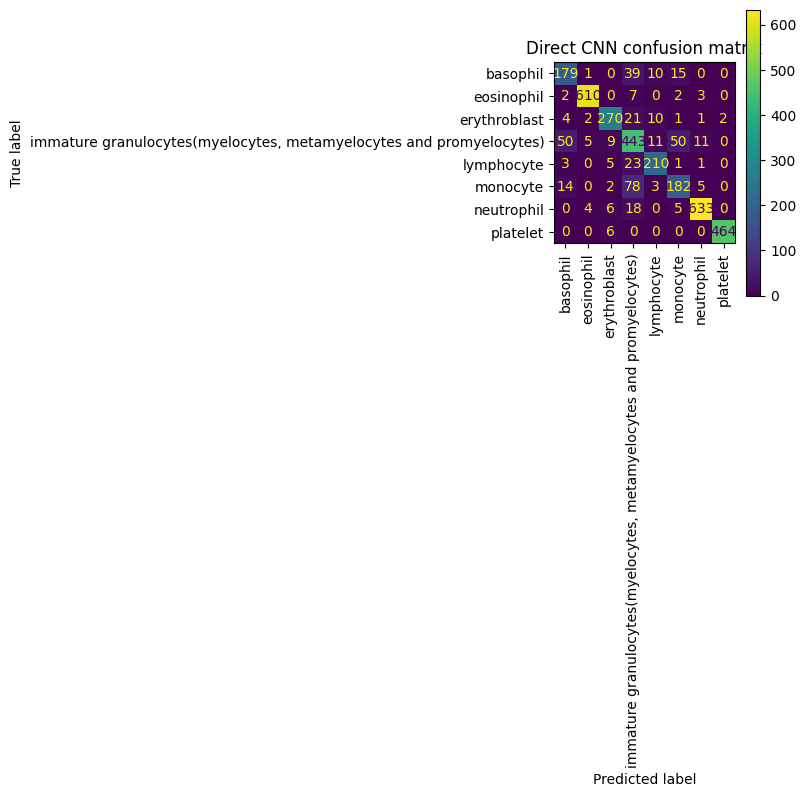

In [2]:


cfg = Config()
set_seed(cfg.random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print("device:", device)
#print("torch version:", torch.__version__)
#print("medmnist version:", medmnist.__version__)

#2: load dataset  ========================================================================
info = INFO[cfg.dataset_flag]
n_channels = info["n_channels"]
n_classes = len(info["label"])
class_names = list(info["label"].values())
DataClass = getattr(medmnist, info["python_class"])

#print("\nDataset metadata")
#print("----------------")
#print("dataset flag:", cfg.dataset_flag)
#print("task        :", info["task"])
#print("n_classes   :", n_classes)
#print("n_channels  :", n_channels)

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset = DataClass(split="val", transform=transform, download=True)
test_dataset = DataClass(split="test", transform=transform, download=True)


#3: load into dataloader  ========================================================================
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

train_loader_probe = DataLoader(train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
test_loader_probe = DataLoader(test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

#4: define and initialize model ========================================================================
sample_x, _ = train_dataset[0]
_, H, W = sample_x.shape
model = SimpleMedMNISTCNN(n_channels, n_classes, input_hw=(H, W)).to(device)

#5: define loss function ========================================================================
criterion = nn.CrossEntropyLoss()

#6: define optimizer and trainig loops ========================================================================
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0
best_state = None

#7: train model ========================================================================
for epoch in range(1, cfg.num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{cfg.num_epochs} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print("\nFinal test")
print("----------")
print(f"Loss: {test_loss:.4f}")
print(f"Acc : {test_acc:.4f}")

epochs = np.arange(1, cfg.num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs, history["val_acc"], marker="o", label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

_ = evaluate_model_directly(model, test_loader, device, class_names=class_names)

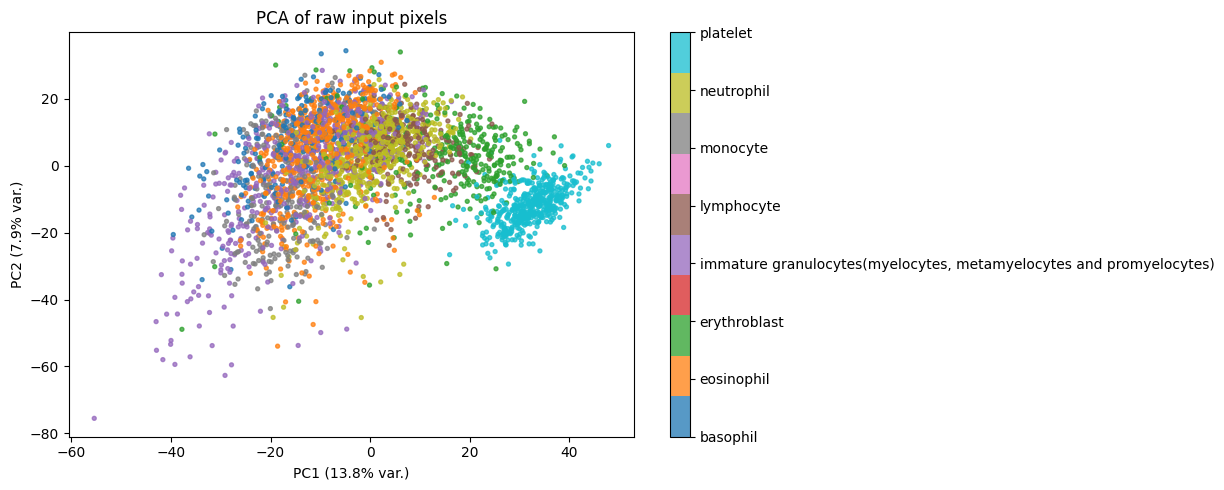


Raw input pixels [N, c*h*w]
---------------------------
Input shape: (3421, 2352)
TwoNN: 30.12

k = 10
MLE : 28.1
TLE : 28.52

k = 20
MLE : 28.1
TLE : 23.82

k = 30
MLE : 28.1
TLE : 22.03

k = 50
MLE : 28.1
TLE : 20.31

Penultimate representation [N, 128]
-----------------------------------
Shape: (3421, 128)
PC1 variance: 0.3976
PC1+PC2 variance: 0.6808
Silhouette score: 0.3297
Nearest-centroid acc: 0.8363


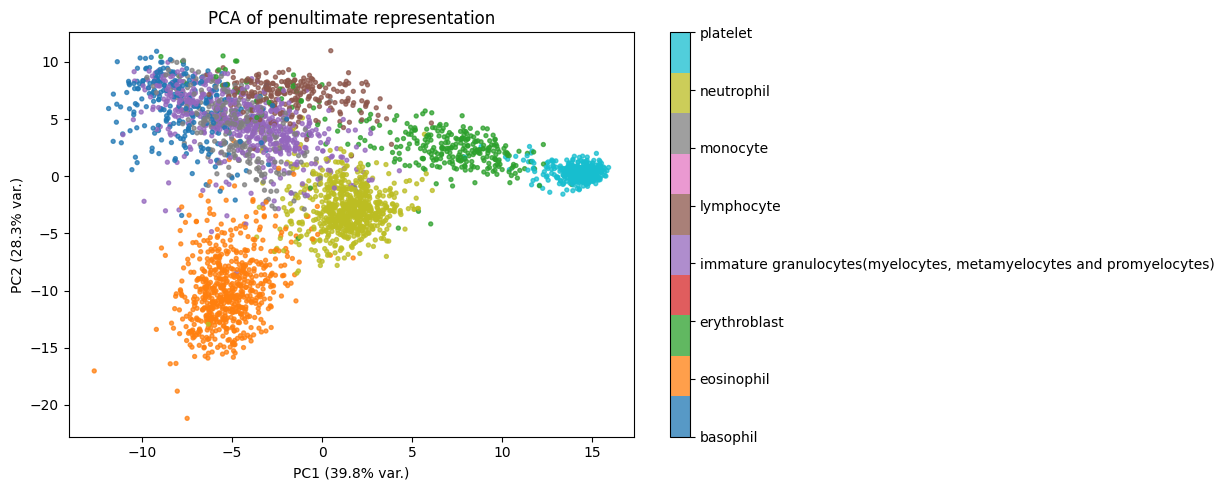


Linear probe
------------
Train accuracy: 0.9141
Test accuracy : 0.8804

Penultimate representation [N, 128]
-----------------------------------
Input shape: (3421, 128)
TwoNN: 6.87

k = 10
MLE : 6.06
TLE : 7.06

k = 20
MLE : 6.06
TLE : 5.99

k = 30
MLE : 6.06
TLE : 5.57

k = 50
MLE : 6.06
TLE : 5.12

Final logits [N, n_classes]
---------------------------
Shape: (3421, 8)
PC1 variance: 0.5099
PC1+PC2 variance: 0.8055
Silhouette score: 0.3678
Nearest-centroid acc: 0.8316


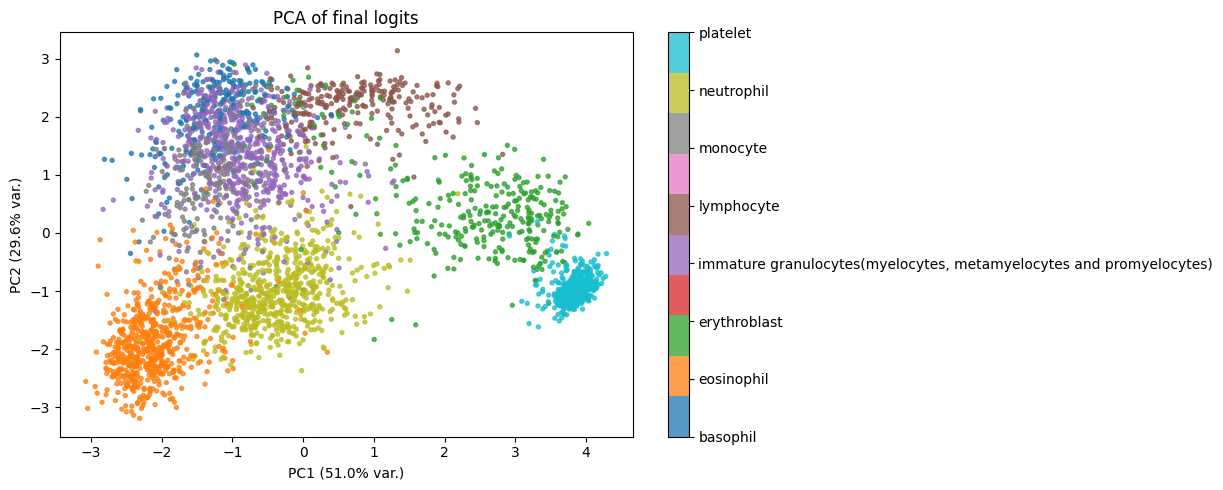


Final logits [N, n_classes]
---------------------------
Input shape: (3421, 8)
TwoNN: 4.93

k = 10
MLE : 4.67
TLE : 5.42

k = 20
MLE : 4.67
TLE : 4.69

k = 30
MLE : 4.67
TLE : 4.4

k = 50
MLE : 4.67
TLE : 4.08


In [3]:

#Probing the raw input representation========================
X_raw, X_flat, y_raw = extract_raw_input_matrix(test_loader_probe)
X_pca_raw, pca_raw, _ = run_pca(X_flat, n_components=2, standardize=True)
plot_pca_scatter(X_pca_raw, y_raw, pca_raw, "PCA of raw input pixels", class_names)
_ = estimate_intrinsic_dimension(X_flat, "Raw input pixels [N, c*h*w]")


#Probing the internal Reprensetation of latent space (penultimate)========================
Z_train_pen, y_train = extract_representations(model, train_loader_probe, device, rep="penultimate")
Z_test_pen, y_test = extract_representations(model, test_loader_probe, device, rep="penultimate")
summarize_representation(Z_test_pen, y_test, "Penultimate representation [N, 128]")
Z_pca_pen, pca_pen, _ = run_pca(Z_test_pen, n_components=2, standardize=True)
plot_pca_scatter(Z_pca_pen, y_test, pca_pen, "PCA of penultimate representation", class_names)
_ = linear_probe(Z_train_pen, y_train, Z_test_pen, y_test) #function evaluates how well a linear classifier can perform on learned representations
_ = estimate_intrinsic_dimension(Z_test_pen, "Penultimate representation [N, 128]")


#Probing the final logits of the mode========================
Z_test_logits, y_test_logits = extract_representations(model, test_loader_probe, device, rep="logits")
summarize_representation(Z_test_logits, y_test_logits, "Final logits [N, n_classes]")
Z_pca_log, pca_log, _ = run_pca(Z_test_logits, n_components=2, standardize=True)
plot_pca_scatter(Z_pca_log, y_test_logits, pca_log, "PCA of final logits", class_names)
_ = estimate_intrinsic_dimension(Z_test_logits, "Final logits [N, n_classes]")

# Null-hypothesis workflow: data vs architecture contributions

This section tests whether low-dimensional structure in the penultimate representation comes from:
1. **Data structure** (real images vs noise),
2. **Architecture bias** (untrained CNN),
3. **Learning signal** (true labels vs shuffled labels).

Raw real input TwoNN ID (reference): 30.123

RUN 1/3 | penultimate dim = 128 | seed = 1322
[pen=128] Epoch 01/30 | train acc: 0.3716 | val acc: 0.5694
[pen=128] Epoch 02/30 | train acc: 0.6494 | val acc: 0.6988
[pen=128] Epoch 03/30 | train acc: 0.7147 | val acc: 0.7433
[pen=128] Epoch 04/30 | train acc: 0.7450 | val acc: 0.7721
[pen=128] Epoch 05/30 | train acc: 0.7662 | val acc: 0.7902
[pen=128] Epoch 06/30 | train acc: 0.7841 | val acc: 0.7682
[pen=128] Epoch 07/30 | train acc: 0.8028 | val acc: 0.7625
[pen=128] Epoch 08/30 | train acc: 0.8120 | val acc: 0.8272
[pen=128] Epoch 09/30 | train acc: 0.8229 | val acc: 0.8356
[pen=128] Epoch 10/30 | train acc: 0.8342 | val acc: 0.8101
[pen=128] Epoch 11/30 | train acc: 0.8361 | val acc: 0.8445
[pen=128] Epoch 12/30 | train acc: 0.8484 | val acc: 0.8451
[pen=128] Epoch 13/30 | train acc: 0.8539 | val acc: 0.8516
[pen=128] Epoch 14/30 | train acc: 0.8597 | val acc: 0.8586
[pen=128] Epoch 15/30 | train acc: 0.8606 | val acc: 0.8497
[pen=128]

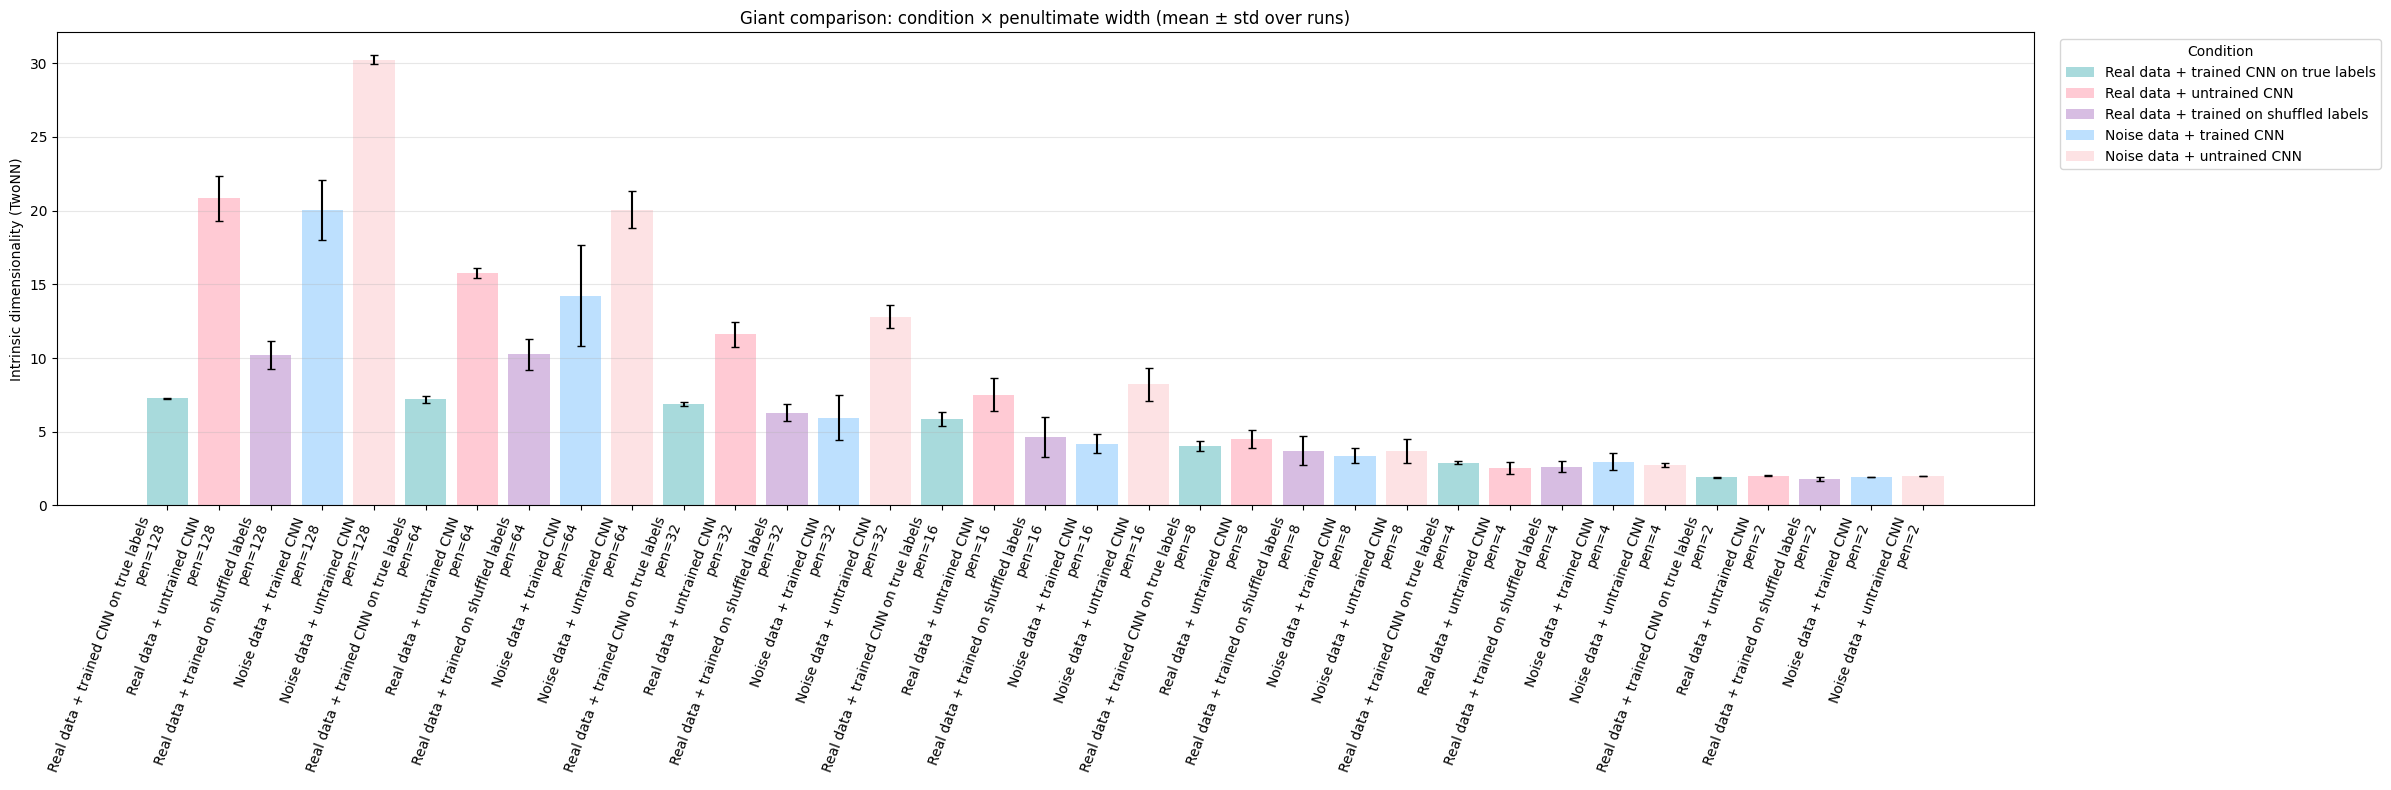

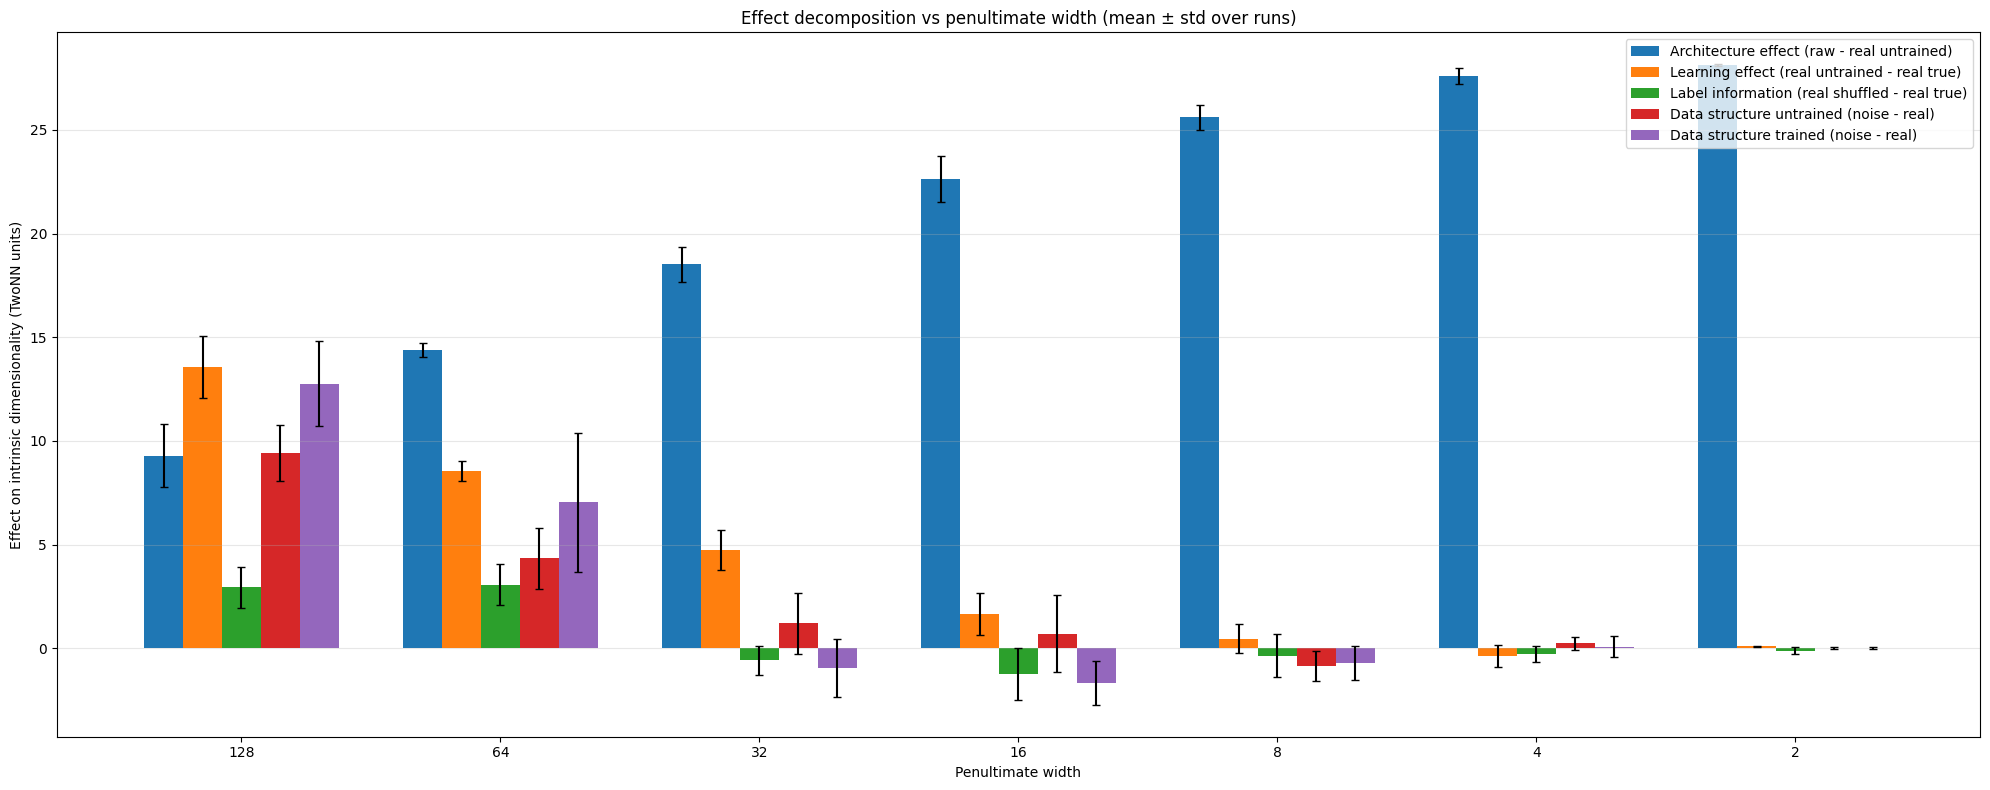

In [20]:
# =========================
# Null-hypothesis experiment with better statistics
# - >= 2 runs per condition
# - Penultimate width sweep
# - Giant bar plots for ID and effect decomposition
# =========================
from collections import defaultdict
from torch.utils.data import Dataset


class LabelShuffledDataset(Dataset):
    # Keep images unchanged but randomly permute labels.
    def __init__(self, base_dataset, seed: int = 42):
        self.base = base_dataset
        rng = np.random.default_rng(seed)

        labels = []
        for i in range(len(base_dataset)):
            _, yi = base_dataset[i]
            labels.append(int(np.array(yi).reshape(-1)[0]))

        self.shuffled_labels = rng.permutation(np.array(labels, dtype=np.int64))

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, _ = self.base[idx]
        y = torch.tensor([int(self.shuffled_labels[idx])], dtype=torch.long)
        return x, y


class GaussianNoiseDataset(Dataset):
    # Generate synthetic images with matched mean/std and random labels.
    def __init__(
        self,
        n_samples: int,
        image_shape: tuple[int, int, int],
        n_classes: int,
        mean: torch.Tensor,
        std: torch.Tensor,
        seed: int = 42,
    ):
        self.n_samples = n_samples
        self.n_classes = n_classes

        generator = torch.Generator().manual_seed(seed)
        channels, height, width = image_shape

        noise = torch.randn(n_samples, channels, height, width, generator=generator)
        mean = mean.view(1, channels, 1, 1)
        std = std.view(1, channels, 1, 1)
        self.x = (noise * std + mean).clamp(0.0, 1.0)
        self.y = torch.randint(low=0, high=n_classes, size=(n_samples,), generator=generator)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx].view(1)


class FlexibleMedMNISTCNN(nn.Module):
    # Same architecture family, but configurable penultimate width.
    def __init__(self, in_channels: int, n_classes: int, pen_dim: int = 128, input_hw: tuple[int, int] = (28, 28)) -> None:
        super().__init__()
        self.pen_dim = pen_dim

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, *input_hw)
            flat_dim = int(np.prod(self.features(dummy).shape[1:]))

        self.flat_dim = flat_dim
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, pen_dim),
            nn.LeakyReLU(),
            nn.Linear(pen_dim, pen_dim),
            nn.LeakyReLU(),
            nn.Linear(pen_dim, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


@torch.no_grad()
def extract_representations_flexible(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    rep: str = "penultimate",
) -> tuple[np.ndarray, np.ndarray]:
    # Extract penultimate/logit/conv representations for flexible-width models.
    model.eval()
    all_z, all_y = [], []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch_np = y_batch.view(-1).cpu().numpy()

        if rep == "penultimate":
            h = model.features(x_batch)
            z = model.classifier[:5](h)
        elif rep == "logits":
            z = model(x_batch)
        elif rep == "conv_flat":
            h = model.features(x_batch)
            z = torch.flatten(h, start_dim=1)
        else:
            raise ValueError("rep must be one of: 'penultimate', 'logits', 'conv_flat'.")

        all_z.append(z.detach().cpu().numpy())
        all_y.append(y_batch_np)

    return np.concatenate(all_z, axis=0), np.concatenate(all_y, axis=0)


def estimate_channel_stats(dataset):
    # Estimate per-channel mean and std from a dataset.
    loader = DataLoader(dataset, batch_size=512, shuffle=False)
    n_total = 0
    channel_sum = None
    channel_sq_sum = None

    for x, _ in loader:
        batch_size = x.size(0)
        x_flat = x.view(batch_size, x.size(1), -1)

        s = x_flat.sum(dim=(0, 2))
        sq = (x_flat**2).sum(dim=(0, 2))

        channel_sum = s if channel_sum is None else channel_sum + s
        channel_sq_sum = sq if channel_sq_sum is None else channel_sq_sum + sq
        n_total += batch_size * x_flat.size(2)

    mean = channel_sum / n_total
    var = channel_sq_sum / n_total - mean**2
    std = torch.sqrt(torch.clamp(var, min=1e-8))
    return mean, std


def train_flexible_model(train_loader_local, val_loader_local, seed: int, pen_dim: int, epochs: int = 6):
    # Train a fresh flexible-width model and keep best-validation checkpoint.
    set_seed(seed)
    m = FlexibleMedMNISTCNN(n_channels, n_classes, pen_dim=pen_dim, input_hw=(H, W)).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=cfg.learning_rate)
    crit = nn.CrossEntropyLoss()

    best_acc = -1.0
    best_state_local = None

    for ep in range(1, epochs + 1):
        _, tr_acc = train_one_epoch(m, train_loader_local, opt, crit, device)
        _, va_acc = evaluate(m, val_loader_local, crit, device)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state_local = copy.deepcopy(m.state_dict())

        print(f"[pen={pen_dim}] Epoch {ep:02d}/{epochs} | train acc: {tr_acc:.4f} | val acc: {va_acc:.4f}")

    if best_state_local is not None:
        m.load_state_dict(best_state_local)
    return m


def twonn_id(Z: np.ndarray) -> float:
    # Fast, single-number intrinsic dimension estimate (TwoNN).
    if not HAS_SKDIM:
        return float("nan")
    Z_scaled = StandardScaler().fit_transform(Z)
    return float(skdim.id.TwoNN().fit_transform(Z_scaled))


def linear_probe_scores(train_Z: np.ndarray, train_y: np.ndarray, test_Z: np.ndarray, test_y: np.ndarray) -> tuple[float, float]:
    # Return train/test probe accuracy without extra printing.
    scaler = StandardScaler()
    train_Z_scaled = scaler.fit_transform(train_Z)
    test_Z_scaled = scaler.transform(test_Z)

    clf = LogisticRegression(max_iter=2000, n_jobs=-1, multi_class="auto")
    clf.fit(train_Z_scaled, train_y)

    train_acc = float(accuracy_score(train_y, clf.predict(train_Z_scaled)))
    test_acc = float(accuracy_score(test_y, clf.predict(test_Z_scaled)))
    return train_acc, test_acc


def run_condition(tag: str, model_for_rep: nn.Module, train_loader_rep: DataLoader, test_loader_rep: DataLoader) -> dict:
    # Run one condition and return ID + probe metrics on penultimate representation.
    Ztr, ytr = extract_representations_flexible(model_for_rep, train_loader_rep, device, rep="penultimate")
    Zte, yte = extract_representations_flexible(model_for_rep, test_loader_rep, device, rep="penultimate")

    tr_probe, te_probe = linear_probe_scores(Ztr, ytr, Zte, yte)
    return {
        "condition": tag,
        "id_penultimate": twonn_id(Zte),
        "probe_train_acc": tr_probe,
        "probe_test_acc": te_probe,
    }


# =========================
# Experiment config
# =========================
# Set the penultimate widths you want to compare here.
pen_dims = [128,64,32,16,8,4,2]
n_runs = 3
epochs_per_training = 30

conditions_order = [
    "Real data + trained CNN on true labels",
    "Real data + untrained CNN",
    "Real data + trained on shuffled labels",
    "Noise data + trained CNN",
    "Noise data + untrained CNN",
]

condition_colors = {
    "Real data + trained CNN on true labels": "#A8DADC",
    "Real data + untrained CNN": "#FFCAD4",
    "Real data + trained on shuffled labels": "#D7BDE2",
    "Noise data + trained CNN": "#BDE0FE",
    "Noise data + untrained CNN": "#FDE2E4",
}


def pen_label(pen_dim: int) -> str:
    # Generate the x-axis label from the current pen_dims value.
    return f"pen={pen_dim}"


# =========================
# Shared data stats + raw ID
# =========================
mean_c, std_c = estimate_channel_stats(train_dataset)
image_shape = (n_channels, H, W)

real_test_probe_for_raw = DataLoader(test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
_, X_flat_raw_for_effects, _ = extract_raw_input_matrix(real_test_probe_for_raw)
id_raw_real = twonn_id(X_flat_raw_for_effects)

print(f"Raw real input TwoNN ID (reference): {id_raw_real:.3f}")


# =========================
# Full sweep: (penultimate width) x (run) x (condition)
# =========================
all_records = []
all_effect_records = []

for pen_dim in pen_dims:
    for run_idx in range(n_runs):
        run_seed = cfg.random_seed + 1000 * run_idx + 10 * pen_dim
        print("\n" + "=" * 90)
        print(f"RUN {run_idx + 1}/{n_runs} | penultimate dim = {pen_dim} | seed = {run_seed}")
        print("=" * 90)

        # Per-run datasets
        shuffled_train_dataset = LabelShuffledDataset(train_dataset, seed=run_seed)
        shuffled_val_dataset = LabelShuffledDataset(val_dataset, seed=run_seed + 1)
        shuffled_test_dataset = LabelShuffledDataset(test_dataset, seed=run_seed + 2)

        noise_train_dataset = GaussianNoiseDataset(
            n_samples=len(train_dataset),
            image_shape=image_shape,
            n_classes=n_classes,
            mean=mean_c,
            std=std_c,
            seed=run_seed,
        )
        noise_test_dataset = GaussianNoiseDataset(
            n_samples=len(test_dataset),
            image_shape=image_shape,
            n_classes=n_classes,
            mean=mean_c,
            std=std_c,
            seed=run_seed + 1,
        )

        # Per-run loaders
        real_train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
        real_val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
        real_train_probe = DataLoader(train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
        real_test_probe = DataLoader(test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

        shuffle_train_loader = DataLoader(shuffled_train_dataset, batch_size=cfg.batch_size, shuffle=True)
        shuffle_val_loader = DataLoader(shuffled_val_dataset, batch_size=cfg.batch_size, shuffle=False)
        shuffle_train_probe = DataLoader(shuffled_train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
        shuffle_test_probe = DataLoader(shuffled_test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

        noise_train_loader = DataLoader(noise_train_dataset, batch_size=cfg.batch_size, shuffle=True)
        noise_val_loader = DataLoader(noise_test_dataset, batch_size=cfg.batch_size, shuffle=False)
        noise_train_probe = DataLoader(noise_train_dataset, batch_size=cfg.probe_batch_size, shuffle=False)
        noise_test_probe = DataLoader(noise_test_dataset, batch_size=cfg.probe_batch_size, shuffle=False)

        # A) Real + Untrained
        untrained_real = FlexibleMedMNISTCNN(n_channels, n_classes, pen_dim=pen_dim, input_hw=(H, W)).to(device)
        rec = run_condition("Real data + untrained CNN", untrained_real, real_train_probe, real_test_probe)
        rec.update({"pen_dim": pen_dim, "run": run_idx + 1, "seed": run_seed})
        all_records.append(rec)

        # B) Real + Trained (True Labels)
        trained_real = train_flexible_model(real_train_loader, real_val_loader, seed=run_seed + 10, pen_dim=pen_dim, epochs=epochs_per_training)
        rec = run_condition("Real data + trained CNN on true labels", trained_real, real_train_probe, real_test_probe)
        rec.update({"pen_dim": pen_dim, "run": run_idx + 1, "seed": run_seed})
        all_records.append(rec)

        # C) Real + Trained (Shuffled Labels)
        trained_shuffle = train_flexible_model(shuffle_train_loader, shuffle_val_loader, seed=run_seed + 20, pen_dim=pen_dim, epochs=epochs_per_training)
        rec = run_condition("Real data + trained on shuffled labels", trained_shuffle, shuffle_train_probe, shuffle_test_probe)
        rec.update({"pen_dim": pen_dim, "run": run_idx + 1, "seed": run_seed})
        all_records.append(rec)

        # D) Noise + Untrained
        untrained_noise = FlexibleMedMNISTCNN(n_channels, n_classes, pen_dim=pen_dim, input_hw=(H, W)).to(device)
        rec = run_condition("Noise data + untrained CNN", untrained_noise, noise_train_probe, noise_test_probe)
        rec.update({"pen_dim": pen_dim, "run": run_idx + 1, "seed": run_seed})
        all_records.append(rec)

        # E) Noise + Trained
        trained_noise = train_flexible_model(noise_train_loader, noise_val_loader, seed=run_seed + 30, pen_dim=pen_dim, epochs=epochs_per_training)
        rec = run_condition("Noise data + trained CNN", trained_noise, noise_train_probe, noise_test_probe)
        rec.update({"pen_dim": pen_dim, "run": run_idx + 1, "seed": run_seed})
        all_records.append(rec)

        # Per-run effect decomposition for this pen_dim
        subset = [r for r in all_records if r["pen_dim"] == pen_dim and r["run"] == run_idx + 1]
        id_map = {r["condition"]: r["id_penultimate"] for r in subset}

        effects = {
            "Architecture effect (raw - real untrained)": id_raw_real - id_map["Real data + untrained CNN"],
            "Learning effect (real untrained - real true)": id_map["Real data + untrained CNN"] - id_map["Real data + trained CNN on true labels"],
            "Label information (real shuffled - real true)": id_map["Real data + trained on shuffled labels"] - id_map["Real data + trained CNN on true labels"],
            "Data structure untrained (noise - real)": id_map["Noise data + untrained CNN"] - id_map["Real data + untrained CNN"],
            "Data structure trained (noise - real)": id_map["Noise data + trained CNN"] - id_map["Real data + trained CNN on true labels"],
        }

        for eff_name, eff_value in effects.items():
            all_effect_records.append(
                {
                    "pen_dim": pen_dim,
                    "run": run_idx + 1,
                    "seed": run_seed,
                    "effect": eff_name,
                    "value": float(eff_value),
                }
            )


# =========================
# Aggregate stats
# =========================
agg_id = defaultdict(list)
for r in all_records:
    agg_id[(r["pen_dim"], r["condition"])].append(r["id_penultimate"])

agg_probe = defaultdict(list)
for r in all_records:
    agg_probe[(r["pen_dim"], r["condition"])].append(r["probe_test_acc"])

agg_eff = defaultdict(list)
for r in all_effect_records:
    agg_eff[(r["pen_dim"], r["effect"])].append(r["value"])

print("\n\nMean ± std of penultimate TwoNN ID by condition and pen_dim")
print("=" * 90)
for pen_dim in pen_dims:
    print(f"\npen_dim = {pen_dim}")
    for cond in conditions_order:
        vals = np.array(agg_id[(pen_dim, cond)], dtype=float)
        print(f"  {cond:<35}: {vals.mean():.3f} ± {vals.std(ddof=0):.3f}")

print("\nMean ± std of linear probe TEST accuracy")
print("=" * 90)
for pen_dim in pen_dims:
    print(f"\npen_dim = {pen_dim}")
    for cond in conditions_order:
        vals = np.array(agg_probe[(pen_dim, cond)], dtype=float)
        print(f"  {cond:<35}: {vals.mean():.3f} ± {vals.std(ddof=0):.3f}")


# =========================
# Giant bar plot 1: ALL condition x pen_dim IDs
# =========================
bar_labels = []
bar_means = []
bar_stds = []
bar_colors = []

for pen_dim in pen_dims:
    for cond in conditions_order:
        vals = np.array(agg_id[(pen_dim, cond)], dtype=float)
        bar_labels.append(f"{cond}\n{pen_label(pen_dim)}")
        bar_means.append(vals.mean())
        bar_stds.append(vals.std(ddof=0))
        bar_colors.append(condition_colors[cond])

x = np.arange(len(bar_labels))
fig, ax = plt.subplots(figsize=(24, 8))
ax.bar(x, bar_means, yerr=bar_stds, capsize=3, color=bar_colors)
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, rotation=70, ha="right")
ax.set_ylabel("Intrinsic dimensionality (TwoNN)")
ax.set_title("Giant comparison: condition × penultimate width (mean ± std over runs)")
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=condition_colors[cond], label=cond) for cond in conditions_order]
ax.legend(handles=legend_handles, title="Condition", loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# Giant bar plot 2: Effect decomposition across pen_dims
# =========================
effect_order = [
    "Architecture effect (raw - real untrained)",
    "Learning effect (real untrained - real true)",
    "Label information (real shuffled - real true)",
    "Data structure untrained (noise - real)",
    "Data structure trained (noise - real)",
]

x = np.arange(len(pen_dims))
width = 0.15
fig, ax = plt.subplots(figsize=(20, 8))

for i, eff in enumerate(effect_order):
    means = []
    stds = []
    for pen_dim in pen_dims:
        vals = np.array(agg_eff[(pen_dim, eff)], dtype=float)
        means.append(vals.mean())
        stds.append(vals.std(ddof=0))

    ax.bar(
        x + (i - (len(effect_order) - 1) / 2) * width,
        means,
        width,
        yerr=stds,
        capsize=3,
        label=eff,
    )

ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in pen_dims])
ax.set_xlabel("Penultimate width")
ax.set_ylabel("Effect on intrinsic dimensionality (TwoNN units)")
ax.set_title("Effect decomposition vs penultimate width (mean ± std over runs)")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# Quick architecture check: conv flatten size vs penultimate widths
probe_model = FlexibleMedMNISTCNN(n_channels, n_classes, pen_dim=max(pen_dims), input_hw=(H, W))
flat_dim = probe_model.flat_dim

print(f"Computed conv flat_dim: {flat_dim}")
print(f"Input resolution: {H}x{W}")
print("Penultimate widths and compression ratio (pen_dim / flat_dim):")
for p in pen_dims:
    ratio = p / flat_dim
    print(f"  pen_dim={p:>4} | ratio={ratio:>6.3f} | compression={flat_dim/p:>6.1f}x")

if min(pen_dims) <= max(4, int(0.05 * flat_dim)):
    print("\nNote: the smallest pen_dim is very narrow relative to flat_dim and can act as a strong bottleneck.")
else:
    print("\nNote: pen_dim choices are moderate relative to flat_dim.")

Computed conv flat_dim: 288
Input resolution: 28x28
Penultimate widths and compression ratio (pen_dim / flat_dim):
  pen_dim= 128 | ratio= 0.444 | compression=   2.2x
  pen_dim=  64 | ratio= 0.222 | compression=   4.5x
  pen_dim=  32 | ratio= 0.111 | compression=   9.0x
  pen_dim=  16 | ratio= 0.056 | compression=  18.0x
  pen_dim=   8 | ratio= 0.028 | compression=  36.0x
  pen_dim=   4 | ratio= 0.014 | compression=  72.0x
  pen_dim=   2 | ratio= 0.007 | compression= 144.0x

Note: the smallest pen_dim is very narrow relative to flat_dim and can act as a strong bottleneck.


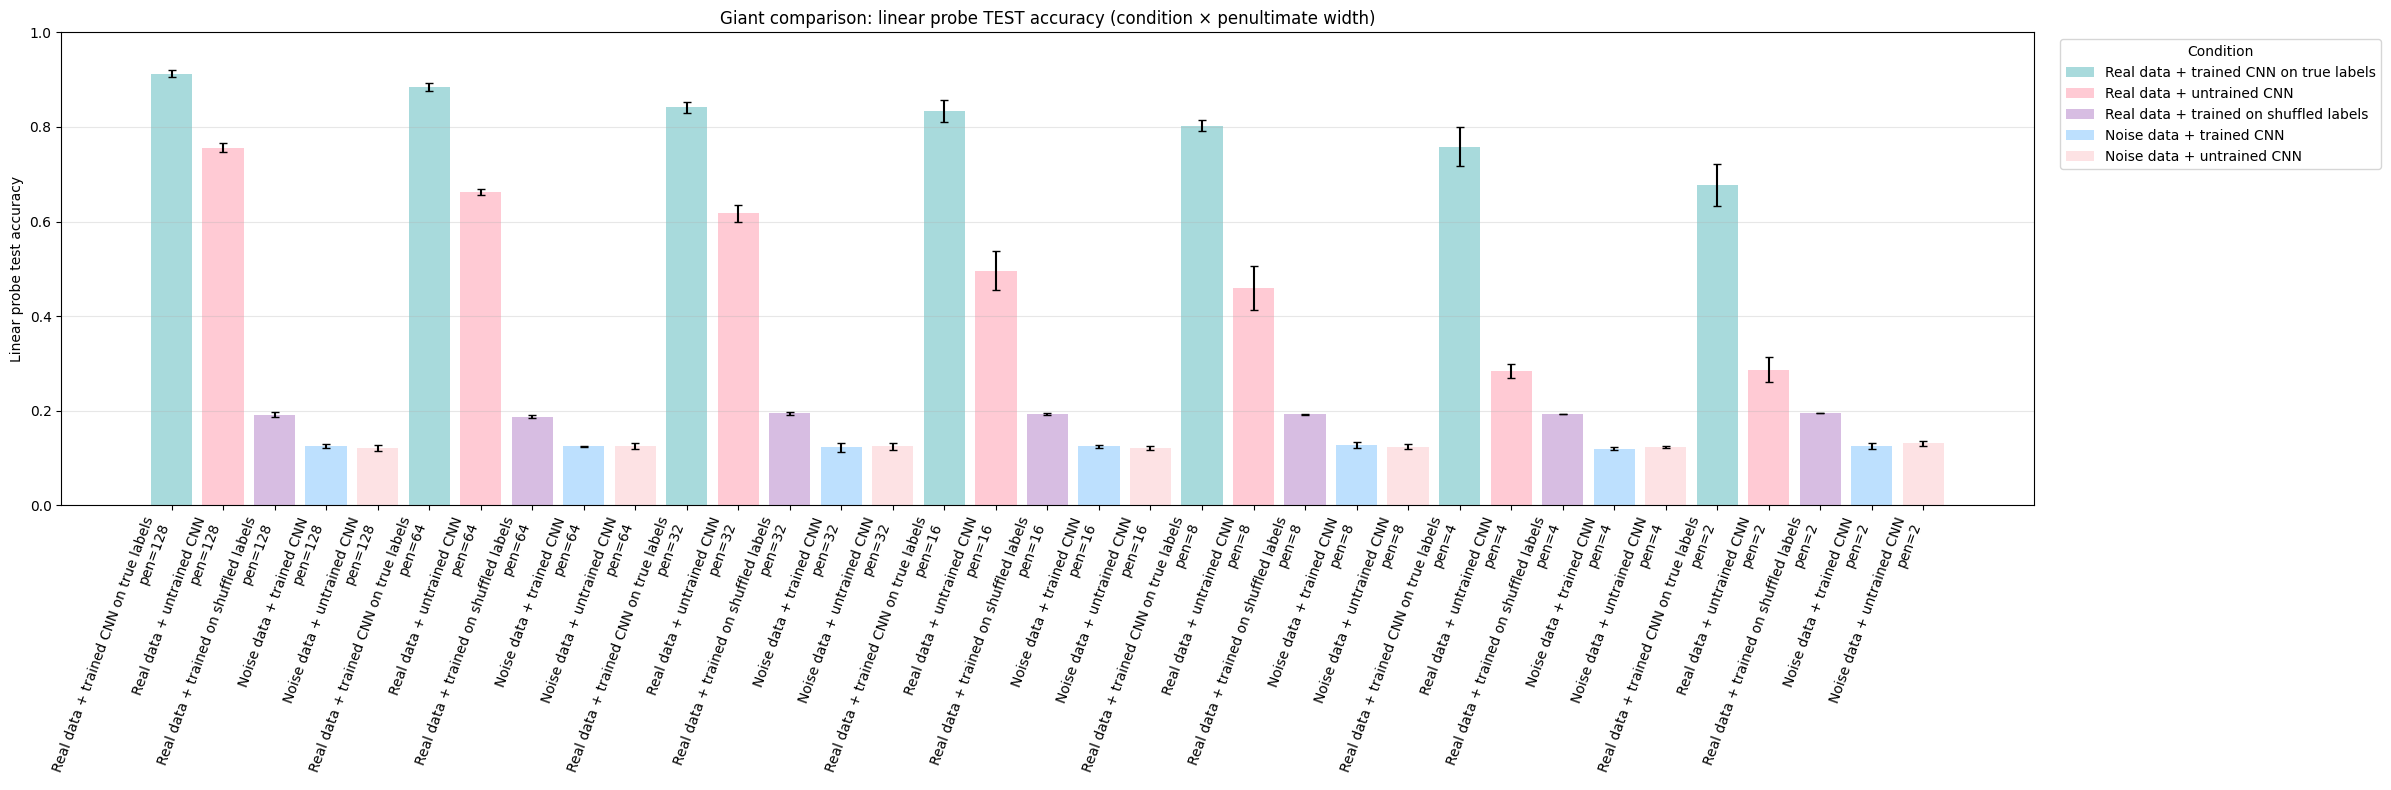

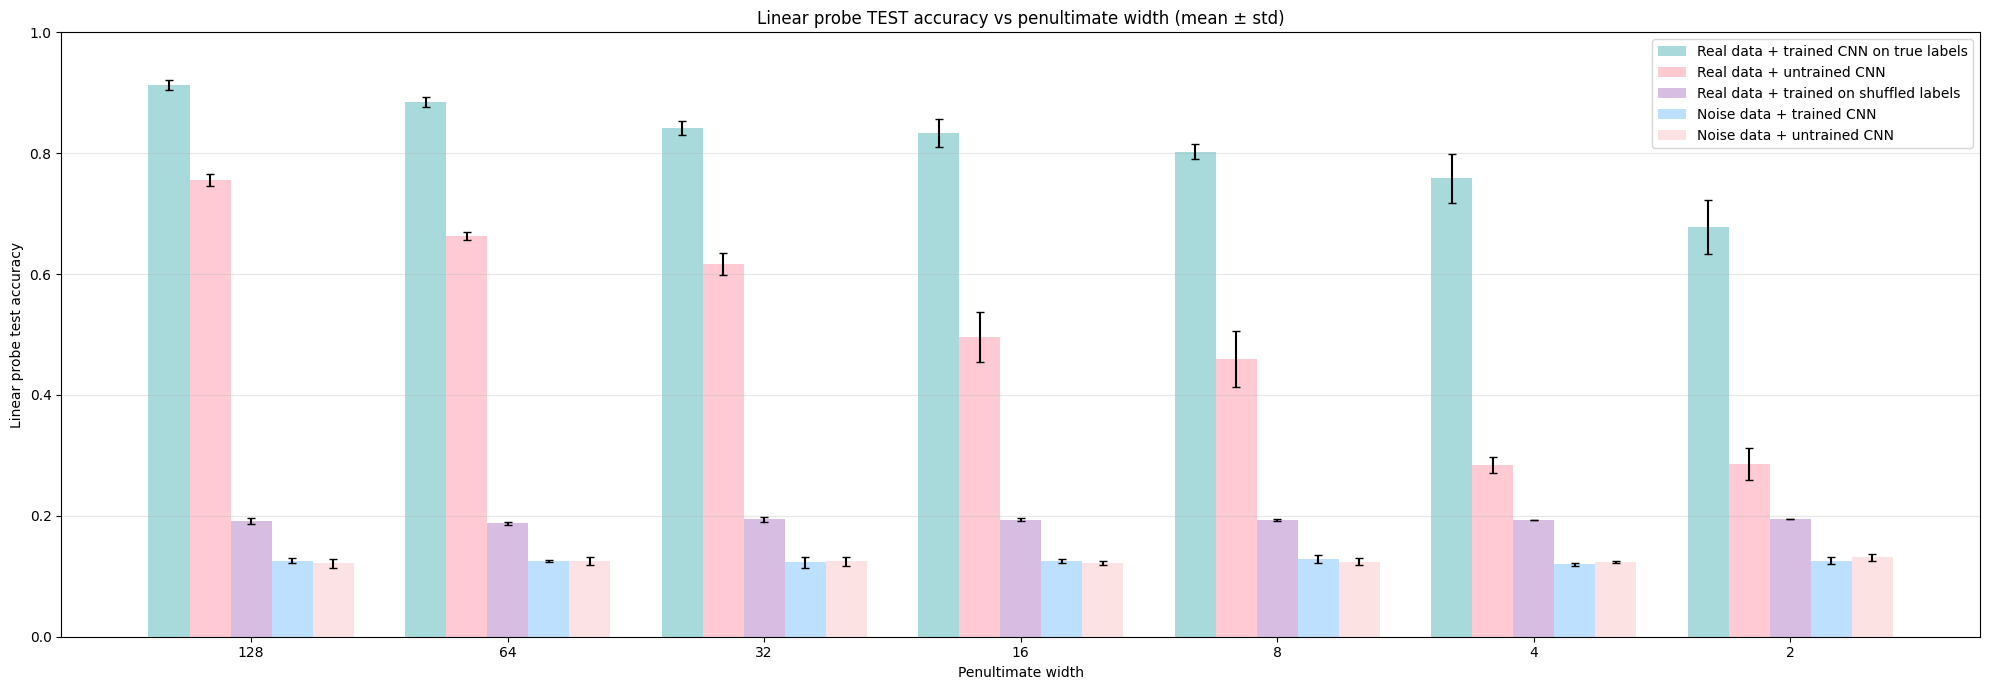

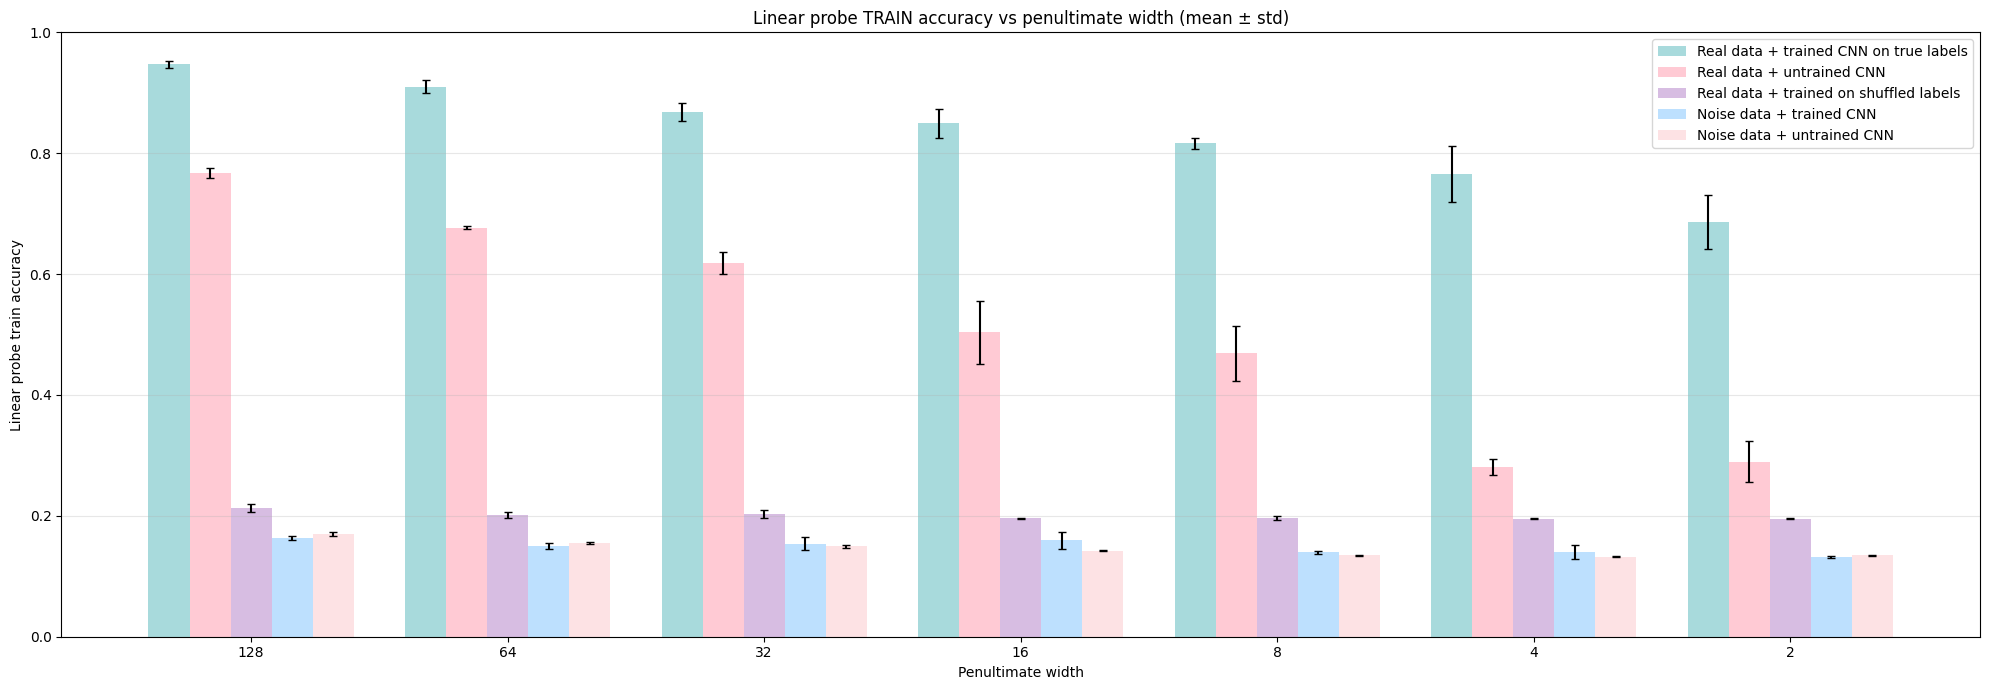

In [22]:
# =========================
# Separate block: accuracy plots
# =========================
# This cell expects `all_records`, `pen_dims`, and `conditions_order` from the previous experiment cell.

from collections import defaultdict

# Aggregate train/test probe accuracies
agg_probe_test = defaultdict(list)
agg_probe_train = defaultdict(list)
for r in all_records:
    agg_probe_test[(r["pen_dim"], r["condition"])].append(r["probe_test_acc"])
    agg_probe_train[(r["pen_dim"], r["condition"])].append(r["probe_train_acc"])

# --- Plot 1: giant bar plot for TEST probe accuracy (condition x pen_dim) ---
labels = []
means = []
stds = []
colors = []

for pen_dim in pen_dims:
    for cond in conditions_order:
        vals = np.array(agg_probe_test[(pen_dim, cond)], dtype=float)
        labels.append(f"{cond}\n{pen_label(pen_dim)}")
        means.append(vals.mean())
        stds.append(vals.std(ddof=0))
        colors.append(condition_colors[cond])

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(24, 8))
ax.bar(x, means, yerr=stds, capsize=3, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=70, ha="right")
ax.set_ylabel("Linear probe test accuracy")
ax.set_title("Giant comparison: linear probe TEST accuracy (condition × penultimate width)")
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=condition_colors[cond], label=cond) for cond in conditions_order]
ax.legend(handles=legend_handles, title="Condition", loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: grouped bars by pen_dim for both train and test accuracy ---
for metric_name, agg_probe in [("TEST", agg_probe_test), ("TRAIN", agg_probe_train)]:
    x = np.arange(len(pen_dims))
    width = 0.16
    fig, ax = plt.subplots(figsize=(20, 7))

    for i, cond in enumerate(conditions_order):
        cond_means = []
        cond_stds = []
        for pen_dim in pen_dims:
            vals = np.array(agg_probe[(pen_dim, cond)], dtype=float)
            cond_means.append(vals.mean())
            cond_stds.append(vals.std(ddof=0))

        ax.bar(
            x + (i - (len(conditions_order) - 1) / 2) * width,
            cond_means,
            width,
            yerr=cond_stds,
            capsize=3,
            label=cond,
            color=condition_colors[cond],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(p) for p in pen_dims])
    ax.set_xlabel("Penultimate width")
    ax.set_ylabel(f"Linear probe {metric_name.lower()} accuracy")
    ax.set_title(f"Linear probe {metric_name} accuracy vs penultimate width (mean ± std)")
    ax.set_ylim(0, 1.0)
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()